<a href="https://colab.research.google.com/github/HugoM1randa/am-t4-s1a2026/blob/main/MultiNeuralCensus0609.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Rondom Forest | Digest Pickle [Fase 1 - census Base]

### Análise do Pipeline Random Forest

O modelo Random Forest alcançou uma acurácia de 83.91%. A matriz de confusão mostrou 3419 Verdadeiros Negativos e 680 Verdadeiros Positivos, mas também 274 Falsos Positivos e 512 Falsos Negativos. O relatório de classificação indica que o modelo tem alta performance para a classe <=50K (F1-score de 0.90), mas desempenho inferior para a classe >50K (F1-score de 0.63). Isso sugere um viés na predição, onde o modelo é mais propenso a classificar instâncias como <=50K.

## Importar dados do Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bibliotecas de Python

In [2]:
!pip -q install plotly
!pip -q install yellowbrick

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census

In [4]:
import pickle

In [5]:
with open('/content/drive/MyDrive/am-t4/census.pkl', 'rb') as f:
  X_census_treinamento, X_census_teste, Y_census_treinamento, Y_census_teste = pickle.load(f)

In [6]:
X_census_treinamento.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [7]:
X_census_teste.shape, Y_census_teste.shape

((4885, 108), (4885,))

In [8]:
from sklearn.ensemble import RandomForestClassifier

In [9]:
random_census = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
random_census.fit(X_census_treinamento, Y_census_treinamento)
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='entropy', max_depth=None, max_features='auto',
                       min_impurity_decrease=0.0, min_samples_split=None,
                       min_samples_leaf=1, min_weight_fraction_leaf=0.0, n_estimators=10,
                       n_jobs=None, oob_score=False, random_state=0, verbose=0, warm_start=False)

RandomForestClassifier(criterion='entropy', max_features='auto',
                       min_samples_split=None, n_estimators=10, random_state=0)

In [10]:

previsores_random = random_census.predict(X_census_teste)
previsores_random

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

## Criando base Previsora

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [12]:
accuracy_score(Y_census_teste, previsores_random)

0.8390992835209826

In [13]:
confusion_matrix(Y_census_teste, previsores_random)

array([[3419,  274],
       [ 512,  680]])

In [14]:
from yellowbrick.classifier import ConfusionMatrix

0.8390992835209826

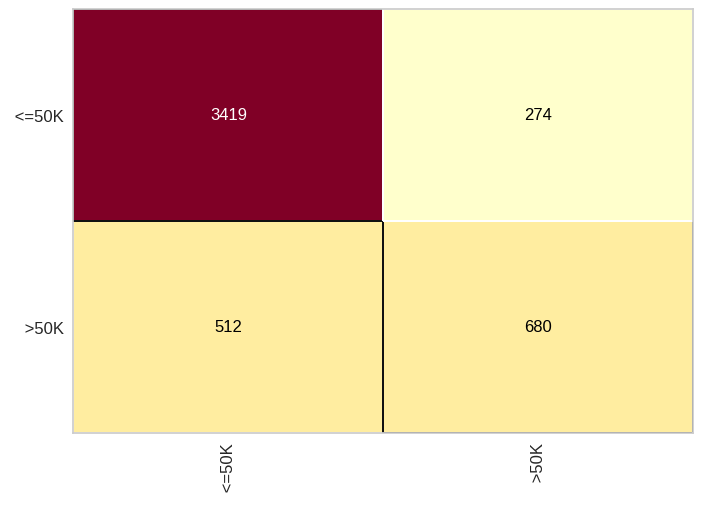

In [15]:
cm_census = ConfusionMatrix(random_census)
cm_census.fit(X_census_treinamento, Y_census_treinamento)
cm_census.score(X_census_teste, Y_census_teste)

In [16]:
print(classification_report(Y_census_teste, previsores_random))

              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      3693
        >50K       0.71      0.57      0.63      1192

    accuracy                           0.84      4885
   macro avg       0.79      0.75      0.77      4885
weighted avg       0.83      0.84      0.83      4885



# Pipeline Regressão | Digest [Fase 1 census Base]

### Análise do Pipeline Regressão Logística

O modelo de Regressão Logística obteve uma acurácia de **84.97%**, superando o Random Forest. Sua performance é equilibrada entre as classes, com um F1-score de 0.90 para <=50K e 0.66 para >50K. Comparado ao Random Forest, este modelo demonstrou uma melhoria na predição da classe >50K, indicando uma capacidade de generalização ligeiramente superior para este problema específico.

In [17]:
from sklearn.linear_model import LogisticRegression


In [18]:
regressao_census = LogisticRegression(random_state=1)
regressao_census.fit(X_census_treinamento, Y_census_treinamento)


LogisticRegression(random_state=1)

In [19]:

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=1, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


LogisticRegression(multi_class='auto', random_state=1)

In [20]:

regression_previsores = regressao_census.predict(X_census_teste)
regression_previsores

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [21]:
accuracy_score(Y_census_teste, regression_previsores)

0.8497441146366428

0.8497441146366428

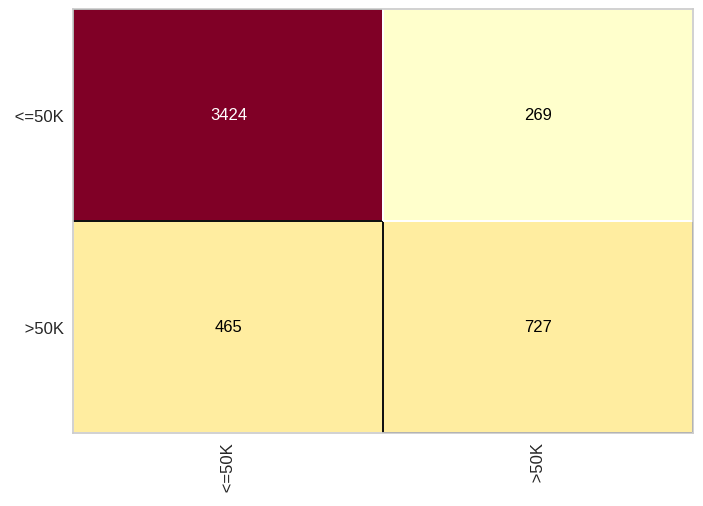

In [22]:
from yellowbrick.classifier import ConfusionMatrix
cm_census = ConfusionMatrix(regressao_census)
cm_census.fit(X_census_treinamento, Y_census_treinamento)
cm_census.score(X_census_teste, Y_census_teste)

In [23]:
print(classification_report(Y_census_teste, regression_previsores))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      3693
        >50K       0.73      0.61      0.66      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.77      0.78      4885
weighted avg       0.84      0.85      0.84      4885



# Pipeline SVM | Digest [Fase 1 census Base]

### Análise do Pipeline SVM

O Support Vector Machine (SVM) apresentou uma acurácia de **84.85%**, similar à Regressão Logística. Embora com um F1-score de 0.90 para <=50K e 0.65 para >50K, o SVM mostrou uma precisão ligeiramente maior para a classe >50K (0.74). Este modelo é robusto e competitivo, com um bom balanço entre a identificação correta das classes e a minimização de falsos positivos.

In [24]:
from sklearn.svm import SVC

In [25]:
svm_census = SVC(kernel='rbf', random_state=1, C=2.0)
svm_census.fit(X_census_treinamento, Y_census_treinamento)


SVC(C=2.0, random_state=1)

In [26]:

SVC(C=2.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=False, random_state=1, shrinking=True, tol=0.001,
    verbose=False)

SVC(C=2.0, random_state=1)

In [27]:

svm_previsoes = svm_census.predict(X_census_teste)
svm_previsoes

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [28]:
accuracy_score(Y_census_teste, svm_previsoes)

0.8485158648925282

0.8485158648925282

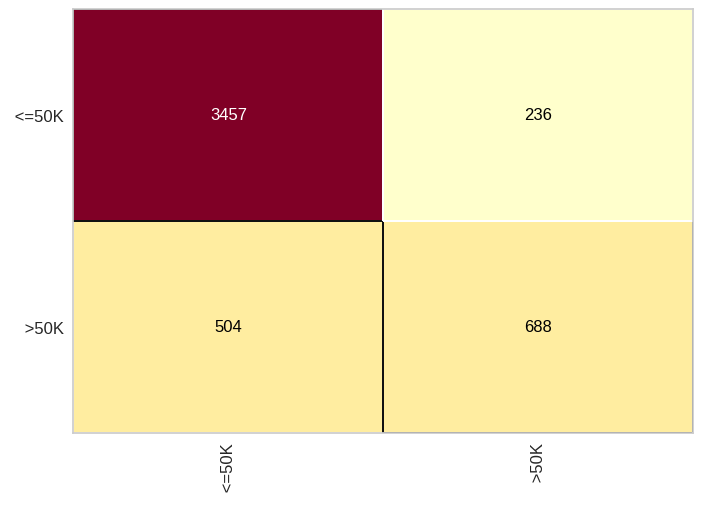

In [29]:
svm_cm = ConfusionMatrix(svm_census)
svm_cm.fit(X_census_treinamento, Y_census_treinamento)
svm_cm.score(X_census_teste, Y_census_teste)

In [30]:
print(classification_report(Y_census_teste, svm_previsoes))

              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90      3693
        >50K       0.74      0.58      0.65      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.76      0.78      4885
weighted avg       0.84      0.85      0.84      4885



# Pipeline Redes Neurais | Digest [Fase 1 census Base]

### Análise do Pipeline Redes Neurais

O modelo de Redes Neurais (MLPClassifier) teve a menor acurácia entre os modelos analisados, com **81.86%**. Embora o F1-score para <=50K seja razoável (0.88), o desempenho para >50K é o mais baixo (F1-score de 0.63), com menor precisão e recall. O treinamento demonstrou que a perda não melhorou significativamente após certo ponto, sugerindo que o modelo pode ter atingido um platô ou que sua arquitetura/hiperparâmetros não foram ideais para a tarefa.

In [31]:
from sklearn.neural_network import MLPClassifier

In [32]:
redeneural_census = MLPClassifier(verbose=True, max_iter=1000, tol=0.000010,
                                  solver = 'adam', hidden_layer_sizes=(100),
                                  activation='relu')
redeneural_census.fit(X_census_treinamento, Y_census_treinamento)

Iteration 1, loss = 0.46358913
Iteration 2, loss = 0.32765284
Iteration 3, loss = 0.31680008
Iteration 4, loss = 0.30996591
Iteration 5, loss = 0.30518142
Iteration 6, loss = 0.30178820
Iteration 7, loss = 0.29904330
Iteration 8, loss = 0.29685280
Iteration 9, loss = 0.29444623
Iteration 10, loss = 0.29247536
Iteration 11, loss = 0.29101560
Iteration 12, loss = 0.28838351
Iteration 13, loss = 0.28760185
Iteration 14, loss = 0.28563393
Iteration 15, loss = 0.28386945
Iteration 16, loss = 0.28285423
Iteration 17, loss = 0.28133650
Iteration 18, loss = 0.28111632
Iteration 19, loss = 0.27920625
Iteration 20, loss = 0.27865604
Iteration 21, loss = 0.27703995
Iteration 22, loss = 0.27594667
Iteration 23, loss = 0.27509101
Iteration 24, loss = 0.27492866
Iteration 25, loss = 0.27297156
Iteration 26, loss = 0.27236671
Iteration 27, loss = 0.27117284
Iteration 28, loss = 0.27102796
Iteration 29, loss = 0.26880033
Iteration 30, loss = 0.26908350
Iteration 31, loss = 0.26727286
Iteration 32, los

MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [33]:
redeneural_census.out_activation_

'logistic'

In [34]:
previsores_redeneural = redeneural_census.predict(X_census_teste)
previsores_redeneural

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype='<U6')

In [35]:
accuracy_score(Y_census_teste, previsores_redeneural)

0.8186284544524053

0.8186284544524053

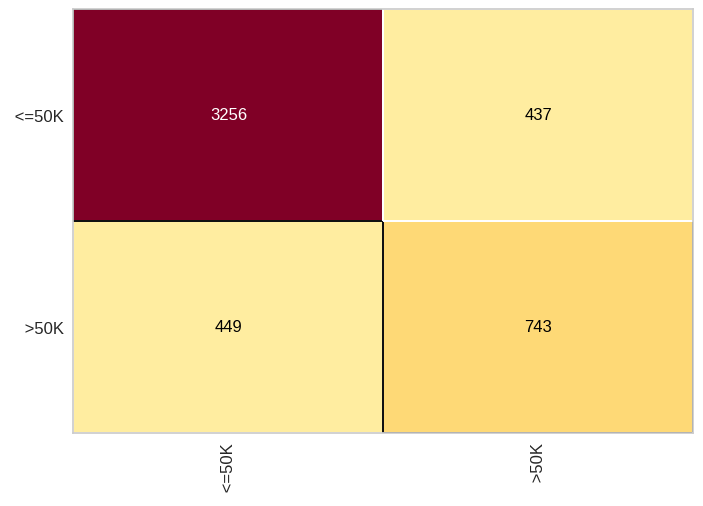

In [36]:
rn_cm = ConfusionMatrix(redeneural_census)
rn_cm.fit(X_census_treinamento, Y_census_treinamento)
rn_cm.score(X_census_teste, Y_census_teste)

In [37]:
print(classification_report(Y_census_teste, previsores_redeneural))

              precision    recall  f1-score   support

       <=50K       0.88      0.88      0.88      3693
        >50K       0.63      0.62      0.63      1192

    accuracy                           0.82      4885
   macro avg       0.75      0.75      0.75      4885
weighted avg       0.82      0.82      0.82      4885



# Pipeline de Preparação dos Dados | Digest [Fase 1 census Base]

### Análise do Pipeline k-NN com GridSearchCV

O GridSearchCV para o KNeighborsClassifier foi utilizado para encontrar os melhores hiperparâmetros n_neighbors e p. Após a codificação dos rótulos (LabelEncoder) para que o KNeighborsClassifier pudesse processar os dados corretamente, o GridSearchCV identificou {'n_neighbors': 10, 'p': 2} como os melhores parâmetros. A melhor acurácia média da validação cruzada foi de **82.82%**. Inicialmente, a execução era lenta, mas foi otimizada com n_jobs=-1 e a redução do espaço de busca dos hiperparâmetros, demonstrando a importância da engenharia de hiperparâmetros e otimização de recursos para modelos computacionalmente intensivos.

In [49]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [50]:
parametros = {'n_neighbors' : [3, 5, 10, 20],
              'p':[1, 2]}

In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
Y_census_treinamento_encoded = le.fit_transform(Y_census_treinamento)
Y_census_teste_encoded = le.transform(Y_census_teste)

print(f"Original Y_census_treinamento samples: {Y_census_treinamento[:5]}")
print(f"Encoded Y_census_treinamento samples: {Y_census_treinamento_encoded[:5]}")
print(f"Original Y_census_teste samples: {Y_census_teste[:5]}")
print(f"Encoded Y_census_teste samples: {Y_census_teste_encoded[:5]}")

Original Y_census_treinamento samples: [' <=50K' ' <=50K' ' <=50K' ' >50K' ' <=50K']
Encoded Y_census_treinamento samples: [0 0 0 1 0]
Original Y_census_teste samples: [' <=50K' ' <=50K' ' <=50K' ' <=50K' ' >50K']
Encoded Y_census_teste samples: [0 0 0 0 1]


In [53]:
grid_census = GridSearchCV(estimator=KNeighborsClassifier(), param_grid = parametros)
grid_census.fit(X_census_treinamento, Y_census_treinamento_encoded) # Corrigido para usar a variável codificada
melhor_parametros_census = grid_census.best_params_
melhor_resultado_census = grid_census.best_score_
print(melhor_parametros_census)
print(melhor_resultado_census)

{'n_neighbors': 20, 'p': 1}
0.8327430212885943
